In [1]:
import sys
sys.path.append(r"C:\Users\jcmar\my_files\SportsBetting")


In [5]:
import numpy as np 
import pandas as pd 

from backtest_plots import plot_backtest, per_bet_analysis
from backtest_plots import event_analysis, plot_event_odds_stats, correlate_with_vegas, summary_stats, pmf_plot, parlay_analysis

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_kelly = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_open.csv')

df_kelly_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close1.csv')
df_parlay_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close1.csv')

df_kelly_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close2.csv')
df_parlay_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close2.csv')

In [ ]:
def pick_accuracy(df_):
    df= df_.copy()

    df_choice = df[df['choice_fstar'] > 0]

    event_accuracy = (
    (df_choice['pred_winner'] == df_choice['winner'])
    .groupby(df_choice['date'])
    .mean()
    )
    n_picks = df_choice.groupby('date').size()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Event accuracy ---
    sns.histplot(event_accuracy, bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f'Event-Level Accuracy\nmean={event_accuracy.mean():.2f}')
    axes[0].set_xlabel('Event-Level Accuracy')
    axes[0].set_ylabel('Frequency')

    # --- Picks per day ---
    n_picks = df_choice.groupby('date').size()

    sns.histplot(n_picks, bins=20, kde=True, ax=axes[1])
    axes[1].set_title(f'Number of Picks per Day\nmean={n_picks.mean():.2f}')
    axes[1].set_xlabel('Number of Picks per Day')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


def bin_parlay_prob(df_parlay_):
    df = df_parlay_.copy()
    df['parlay_win'] = 

    # --- bin probabilities ---
    df['prob_bin'] = pd.cut(
        df['parlay_prob'],
        bins=np.linspace(0, 1, 11),
        include_lowest=True
    )

    # --- ensure win column exists ---
    # if not already present, uncomment/adapt:
    # df['parlay_win'] = (df['winner'] == df['pred_winner']).astype(int)

    # --- aggregations ---
    agg = (
        df.groupby('prob_bin')
        .agg(
            expected_net_odds=('parlay_net_odds', 'mean'),
            accuracy=('parlay_win', 'mean'),
            count=('parlay_win', 'size')
        )
        .reset_index()
    )

    # --- plots ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # expected net odds
    sns.barplot(data=agg, x='prob_bin', y='expected_net_odds', ax=axes[0])
    axes[0].set_title('Expected Net Odds by Parlay Probability Bin')
    axes[0].set_xlabel('Probability Bin')
    axes[0].set_ylabel('Expected Net Odds')
    axes[0].tick_params(axis='x', rotation=45)

    # accuracy
    sns.barplot(data=agg, x='prob_bin', y='accuracy', ax=axes[1])
    axes[1].set_title('Accuracy by Parlay Probability Bin')
    axes[1].set_xlabel('Probability Bin')
    axes[1].set_ylabel('Win Rate')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return agg



In [31]:
bin_parlay_prob(df_parlay)
bin_parlay_prob(df_parlay_close1)
bin_parlay_prob(df_parlay_close2)

C:\Users\jcmar\AppData\Local\Temp\ipykernel_51908\2869259801.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('prob_bin')


KeyError: "Column(s) ['parlay_win'] do not exist"

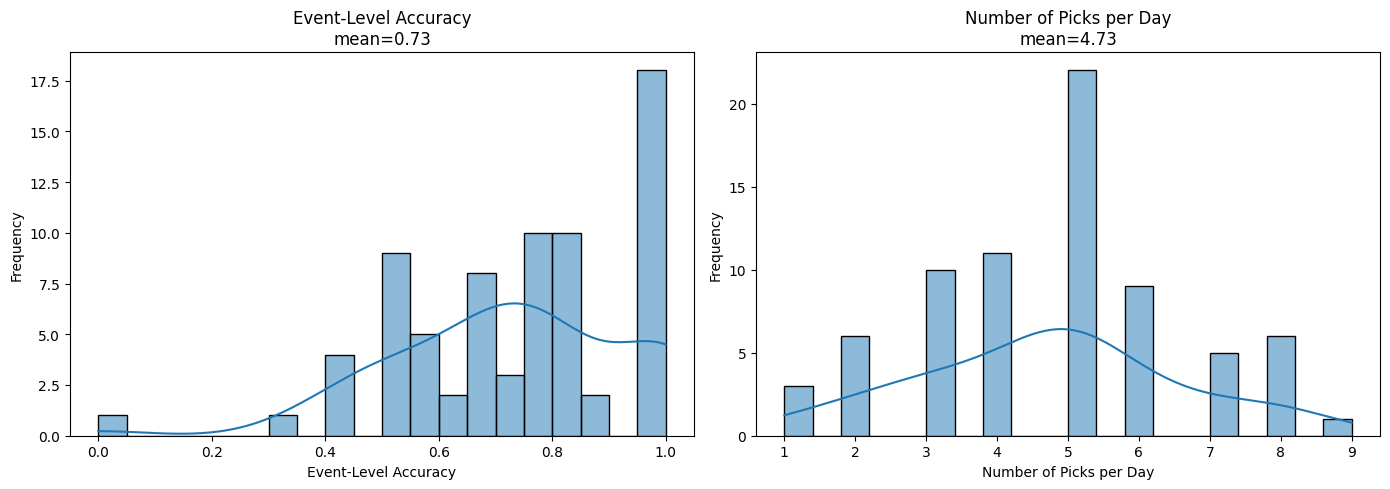

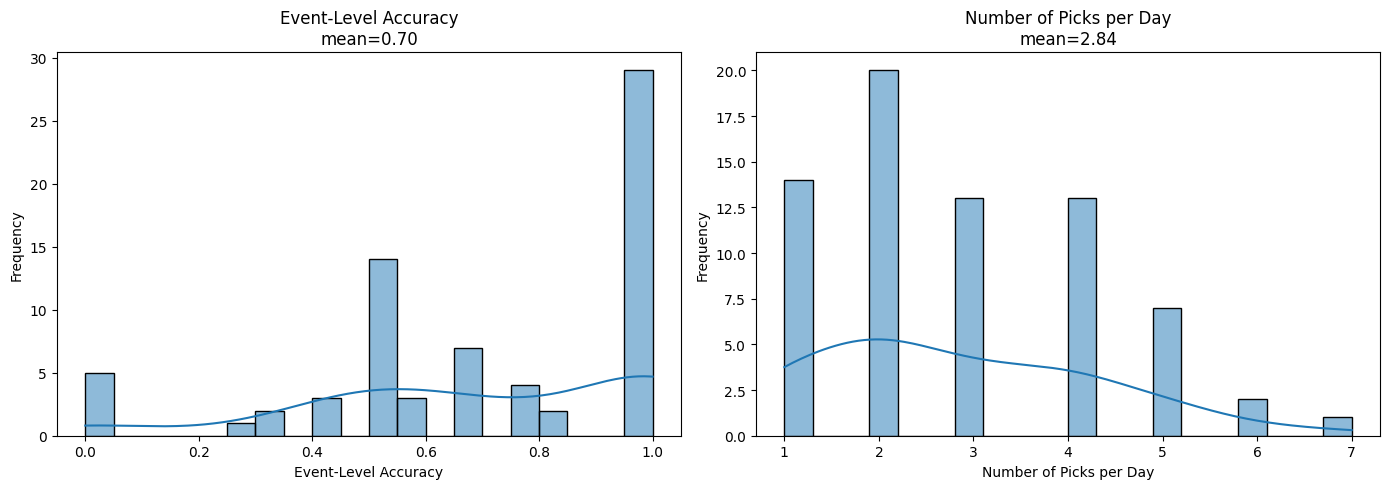

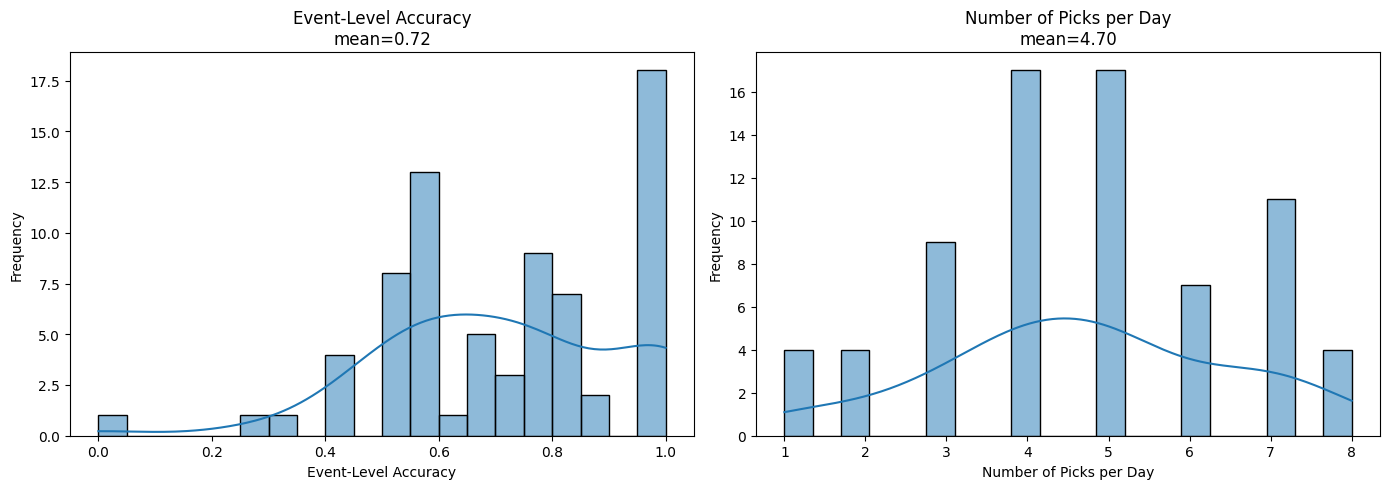

In [18]:
pick_accuracy(df_kelly)
pick_accuracy(df_kelly_close1)
pick_accuracy(df_kelly_close2)

In [4]:
df_kelly

,Unnamed: 0,fight_payout,choice_fstar,net_odds,choice_ev,choice_juice,choice_decimal_odds,parlay_net,parlay_net_odds,bankroll_pct_change,...,juice_open_red,juice_open_blue,juice_close1_red,juice_close1_blue,juice_close2_red,juice_close2_blue,close1_red,close1_blue,close2_red,close2_blue
0,0,0.000000e+00,0.000000,0.00000,-0.031171,0.019340,1.704225,-1.381897e+02,-1.0,-0.711487,...,0.021982,0.019340,0.052837,0.037833,0.010070,0.007474,154.0,-230.0,185.0,-200.0
1,1,0.000000e+00,0.000000,0.00000,-0.083463,0.019162,1.588235,-1.381897e+02,-1.0,-0.711487,...,0.023691,0.019162,0.038462,0.024857,0.010626,0.007211,205.0,-278.0,225.0,-245.0
2,2,1.224346e+01,0.122435,0.20000,0.009961,0.013795,1.200000,-1.381897e+02,-1.0,-0.711487,...,0.013795,0.027871,0.017797,0.039346,0.011175,0.023421,-600.0,400.0,-549.0,430.0
3,3,-4.259002e+01,0.085180,-1.00000,0.111903,0.021593,2.100000,-1.381897e+02,-1.0,-0.711487,...,0.019815,0.021593,0.034613,0.038254,0.004819,0.005282,-141.0,105.0,-125.0,120.0
4,4,0.000000e+00,0.000000,0.00000,-0.018855,0.017947,1.238095,-1.381897e+02,-1.0,-0.711487,...,0.017947,0.033648,0.026668,0.062221,0.001009,0.001964,-650.0,350.0,-485.0,475.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,622,4.143577e+06,0.112190,0.80000,0.219372,0.020969,1.800000,-1.217346e+07,-1.0,-0.172507,...,0.022391,0.020969,0.050930,0.033280,0.008060,0.005515,185.0,-275.0,225.0,-240.0
623,623,3.871793e+06,0.176116,0.47619,0.203325,0.014588,1.476190,-1.217346e+07,-1.0,-0.172507,...,0.014588,0.019974,0.031300,0.062953,-0.001494,-0.002528,-480.0,275.0,-342.0,350.0
624,624,-9.827850e+06,0.212876,-1.00000,0.237507,0.024320,1.408163,-1.217346e+07,-1.0,-0.172507,...,0.035475,0.024320,0.045305,0.028961,0.013136,0.008842,200.0,-286.0,225.0,-250.0
625,625,6.021786e+06,0.081522,1.60000,0.375119,0.019019,2.600000,-1.217346e+07,-1.0,-0.172507,...,0.019019,0.014719,0.036163,0.034005,0.014910,0.014179,-102.0,-130.0,105.0,-118.0


In [10]:
def compare_parlay(parlay_open, parlay_close): 

    n_same = 0
    n_diff = 0

    net_odds_same = 0
    net_odds_diff = 0

    wins_same = 0
    wins_diff = 0

    for date, group_open in parlay_open.groupby('date'):
        group_close = parlay_close[parlay_close['date'] == date]

        net_odds = group_open['parlay_net_odds'].iloc[0] - group_close['parlay_net_odds'].iloc[0]

        if (group_close['choice_fighter_name'] == group_open['choice_fighter_name']).all():
            n_same += 1
            net_odds_same += net_odds
            if group_open['parlay_net_odds'].iloc[0] > 0:
                wins_same += 1
        else:
            n_diff += 1
            net_odds_diff += net_odds
            if group_open['parlay_net_odds'].iloc[0] > 0:
                wins_diff += 1

    print(f"Same choice: {n_same}, Diff choice: {n_diff}, net_odds_diff: {net_odds_diff}, net_odds_same: {net_odds_same} wins_same: {wins_same}, wins_diff: {wins_diff}")
            

compare_parlay(df_parlay, df_parlay_close1)
compare_parlay(df_parlay, df_parlay_close2)

Same choice: 17, Diff choice: 57, net_odds_diff: 30.084348875334854, net_odds_same: 10.708691562715263 wins_same: 14, wins_diff: 30
Same choice: 14, Diff choice: 60, net_odds_diff: 36.98800149712378, net_odds_same: 4.06405970966395 wins_same: 10, wins_diff: 34


In [ ]:
df_parlay['choice_fighter_name']

,Unnamed: 0,choice_fighter_name,fstar_parlay,choice_ev,choice_real_odds,parlay_net_odds,pred_winner,choice_proba,parlay_prob,parlay_ev,date,winner,fstar_net,choice_decimal_odds
0,6,jonathan martinez,0.276379,0.250932,1.854701,-1.000000,0,0.674466,0.574733,0.393945,2024-05-04,1.0,-0.276379,1.854701
1,5,vitor petrino,0.276379,0.114325,1.307692,-1.000000,0,0.852131,0.574733,0.393945,2024-05-04,1.0,-0.276379,1.307692
2,0,chase hooper,0.118623,0.357386,2.640000,-1.000000,1,0.514161,0.260087,0.620445,2024-05-11,1.0,-0.118623,2.640000
3,6,rodrigo nascimento,0.118623,0.193799,2.360000,-1.000000,0,0.505847,0.260087,0.620445,2024-05-11,1.0,-0.118623,2.360000
4,0,luana pinheiro,0.221894,0.430233,2.200000,-1.000000,1,0.650106,0.414813,0.673077,2024-05-18,0.0,-0.221894,2.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,3,benoit st denis,0.180089,0.071023,1.377358,0.836478,0,0.777592,0.626547,0.150640,2026-01-31,0.0,0.180089,1.377358
144,9,julius walker,0.288505,0.417410,2.450000,-1.000000,0,0.578535,0.506309,0.653944,2026-02-07,1.0,-0.288505,2.450000
145,4,klaudia sygula,0.288505,0.166878,1.333333,-1.000000,1,0.875158,0.506309,0.653944,2026-02-07,1.0,-0.288505,1.333333
146,7,serghei spivac,0.263683,0.375119,2.600000,-1.000000,1,0.528892,0.464795,0.701719,2026-02-21,1.0,-0.263683,2.600000


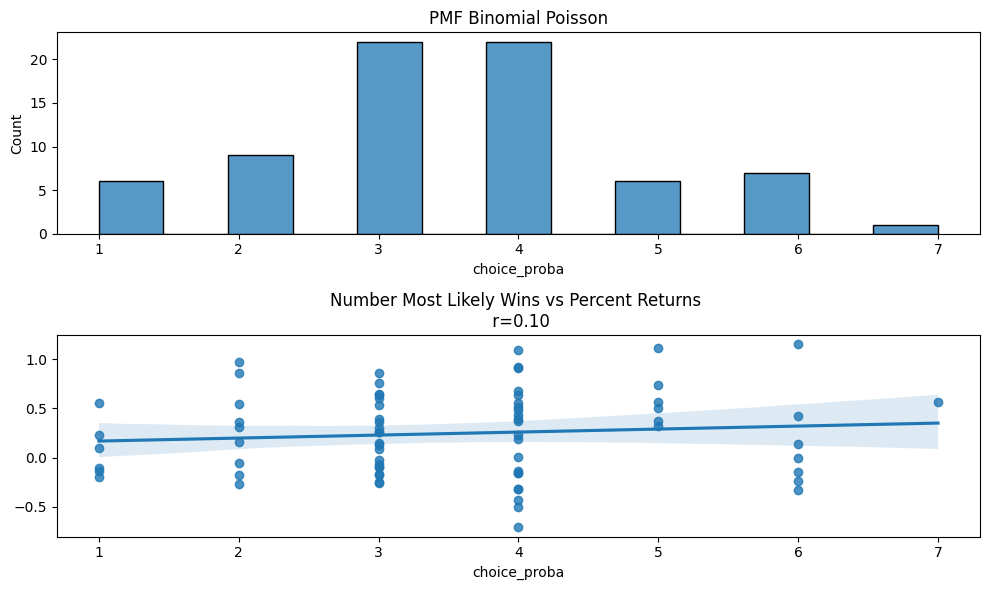

In [8]:
pmf_plot(df_kelly)

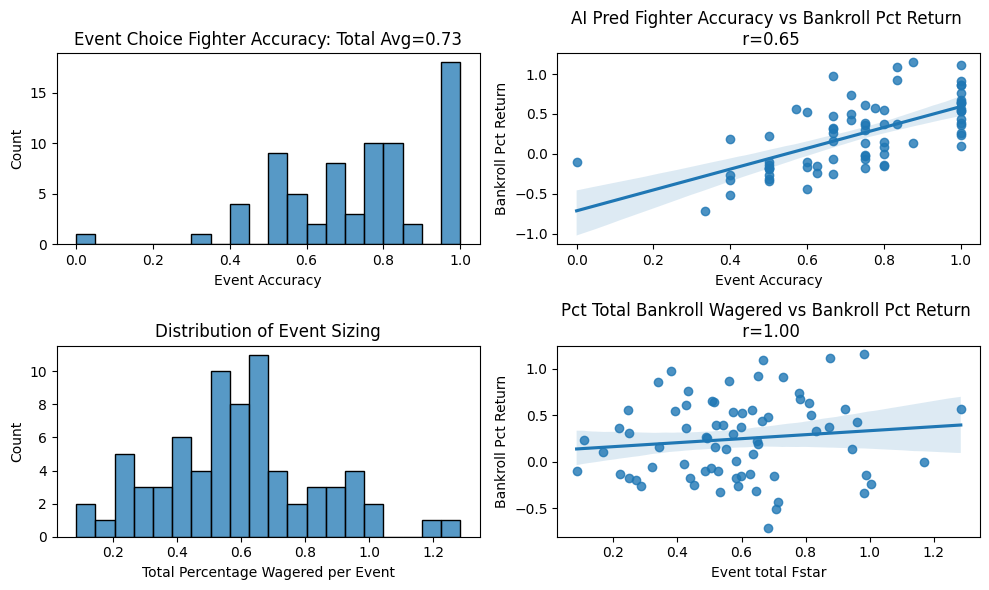

In [9]:
summary_stats(df_kelly)

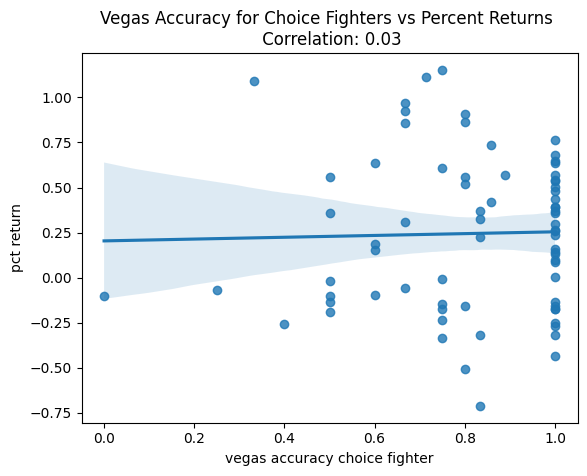

In [10]:
correlate_with_vegas(df_kelly)

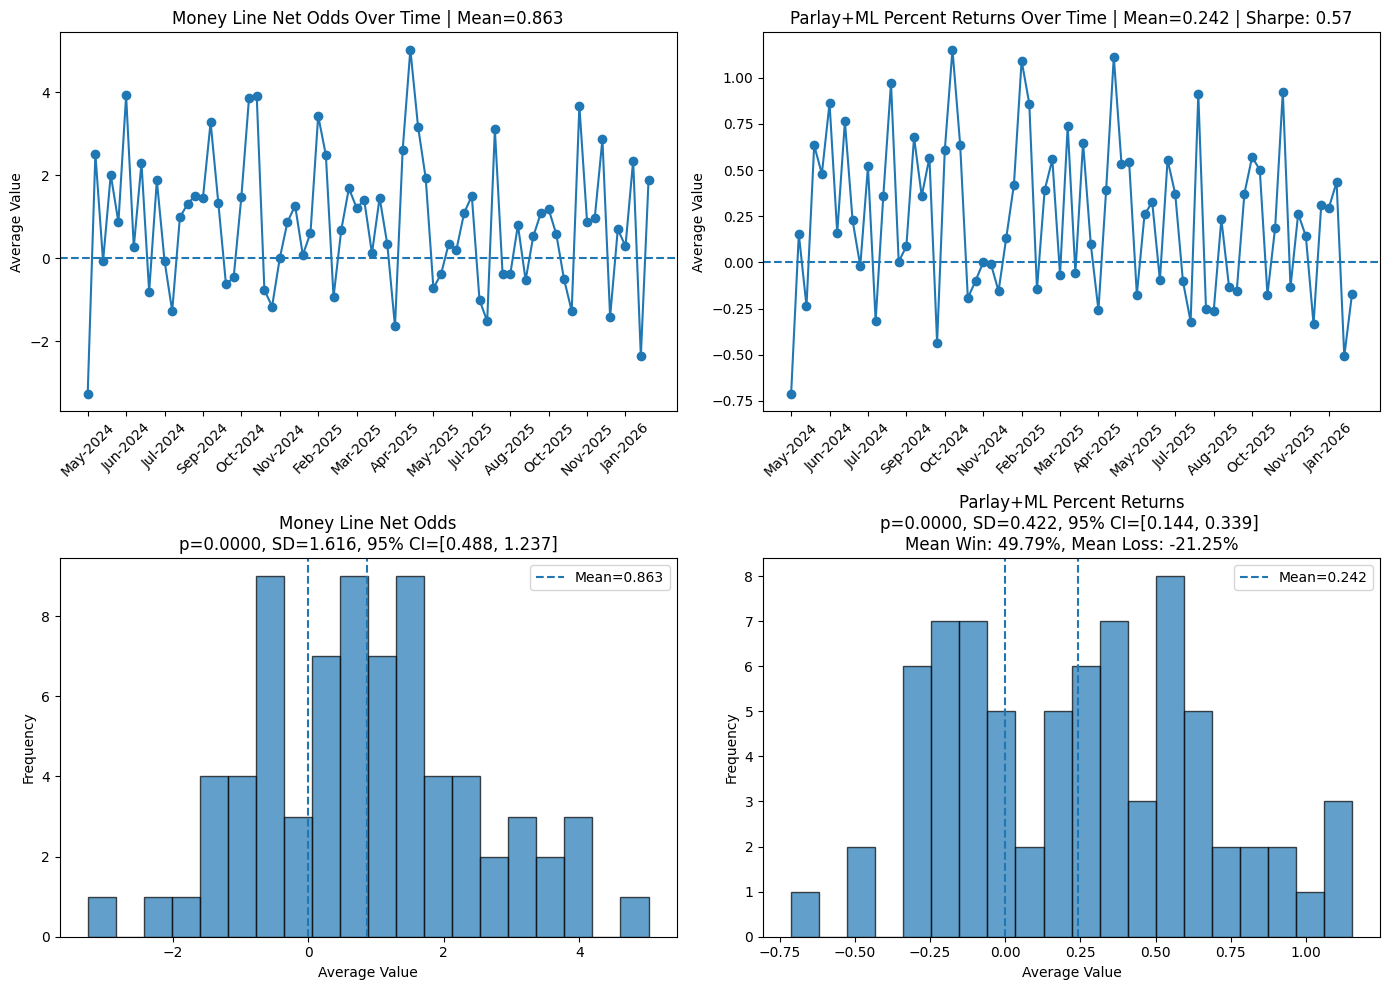

In [11]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_open.png'
plot_event_odds_stats(df_kelly, path)

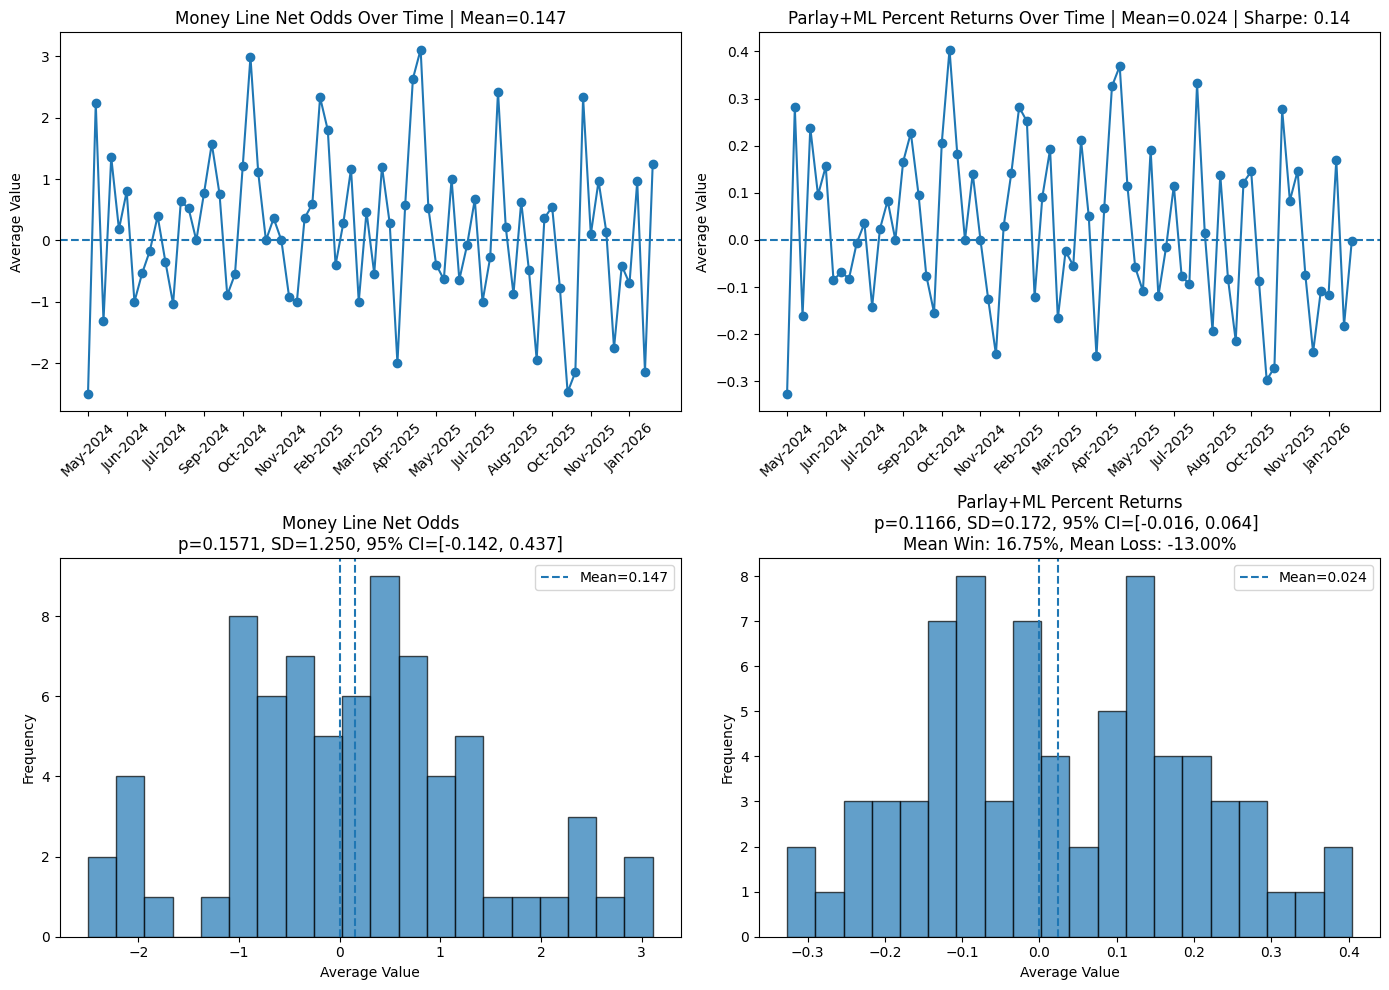

In [12]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_close1.png'
plot_event_odds_stats(df_kelly_close1, path)

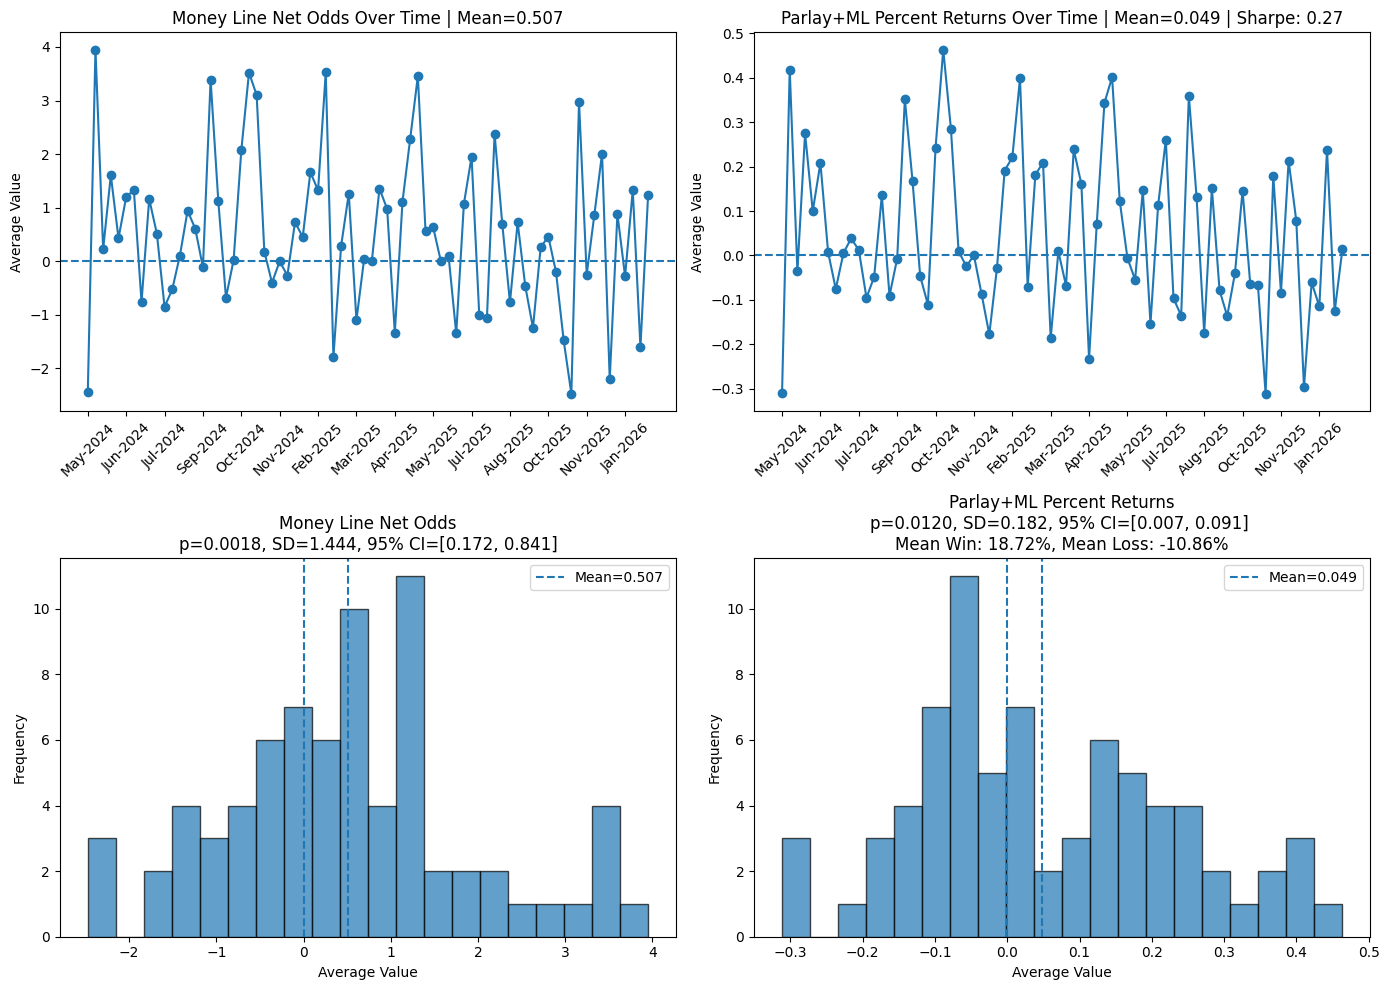

In [13]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_close2.png'
plot_event_odds_stats(df_kelly_close2, path)

In [ ]:
def calc_parlay_multiplier(df_parlay):

    choice_ev = df_parlay[df_parlay['parlay_ev'] > 0]

    # choice_ev['net_fstar'] = np.where(choice_ev['parlay_net_odds'] < 0, -choice_ev['parlay_fstar_sum'],
    #                     choice_ev['parlay_fstar_sum'])

    total = np.sum(choice_ev['fstar_parlay'] * choice_ev['parlay_net_odds']) / 2
    print(total)

def calc_ml_multiplier(df_kelly):

    choice_kelly = df_kelly[df_kelly['choice_ev'] > 0]

    total = np.sum(choice_kelly['choice_fstar'] * choice_kelly['net_odds'])
    print(total)
    print(f'Total Bets: {choice_kelly.shape[0]}')


def compare_parlays(df_open, df_close): 
    assert df_open.shape == df_close.shape, 'shape mismatch'

    choice_open = df_open[df_open['parlay_ev'] > 0]
    open_acc = np.mean(np.where(choice_open['parlay_net_odds'] > 0, 1, 0))
   
    choice_open_close = df_close[df_open['parlay_ev'].values > 0]

    choice_close = df_close[df_close['parlay_ev'] > 0]
    close_acc = np.mean(np.where(choice_close['parlay_net_odds'] > 0, 1, 0))


    n_same = 0
    for date, group in choice_open.groupby('date'):

        group_close = choice_open_close[choice_open_close['date']==date]
        if set(group_close['choice_fighter_name']) == set(group['choice_fighter_name']):

            n_same += 1
    
    avg_net_odds_open = choice_open['parlay_net_odds'].mean()
    avg_net_odds_close = choice_close['parlay_net_odds'].mean()

    print(f'Avg net odds open: {avg_net_odds_open}')
    print(f'Avg net odds close: {avg_net_odds_close}')

    print(f'Close Accuracy: {close_acc}')
    print(f'Open Accuracy: {open_acc}')

    print(f'Percentage of time same parlay: {n_same/(choice_open.shape[0]/2)}')


def compare_ml(df_kelly, df_kelly1):
    assert df_kelly.shape == df_kelly1.shape, 'wrong shapes'

    choice_kelly = df_kelly[df_kelly['choice_ev'] > 0]
    choice_kelly1 = df_kelly1[df_kelly['choice_ev'] > 0]

    # when open pred is the same as close 
    same_pred = choice_kelly[choice_kelly['pred_winner'] == choice_kelly1['pred_winner']]
    same_pred_kelly1 = choice_kelly1[choice_kelly['pred_winner'] == choice_kelly1['pred_winner']]

    # same pred close ev greater than 0 
    kelly1_same_plus_ev = same_pred_kelly1[same_pred_kelly1['choice_ev'] > 0].shape[0] / same_pred_kelly1.shape[0]

    # same pred average ev change 
    avg_ev_change = same_pred['choice_ev'].mean() - same_pred_kelly1['choice_ev'].mean()

    # avg ev same pred 
    avg_ev_open = same_pred['choice_ev'].mean() 

    # frequency of open pred being the same as close 
    same_pred_frequency = same_pred.shape[0] / choice_kelly.shape[0]

    # accuracy of same pred 
    same_pred_accuracy = np.mean(np.where(same_pred['pred_winner'] == same_pred['winner'], 1, 0))

    # average same pred net odds 
    same_pred_net_avg_open = same_pred['net_odds'].mean()
    same_pred_net_avg_close = same_pred_kelly1['net_odds'].mean()

    print(f'Accuracy of plus ev open fighter with close odds pred: {same_pred_accuracy}')
    print(f'Percentage of time plus ev open fighter same as close odds pred: {same_pred_frequency}')
    print(f'Percentage of time close fighter has plus ev when open fighter has plus ev: {kelly1_same_plus_ev}')
    print(f'Average difference in expected value: {avg_ev_change}')
    print(f'Avg Open plus ev same pred as close: {avg_ev_open}')
    print(f'Same pred open avg net odds: {same_pred_net_avg_open}')
    print(f'Same Pred close net odds average: {same_pred_net_avg_close}')


In [ ]:
calc_parlay_multiplier(df_parlay)
calc_parlay_multiplier(df_kelly1_parlay)
calc_parlay_multiplier(df_kelly2_parlay)

In [ ]:
calc_ml_multiplier(df_kelly)
calc_ml_multiplier(df_kelly1)
calc_ml_multiplier(df_kelly2)

In [ ]:
compare_parlays(df_parlay.reset_index(drop=True), df_kelly1_parlay.reset_index(drop=True))
compare_parlays(df_parlay.reset_index(drop=True), df_kelly2_parlay.reset_index(drop=True))


In [ ]:

compare_ml(df_kelly, df_kelly1) 
compare_ml(df_kelly, df_kelly2) 

c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\Backtest\backtest_plots.py:636: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_per_bin = df_parlay.groupby('ev_bin')['parlay_net_odds'].apply(lambda x: (x != -1).sum() / len(x)).reset_index()


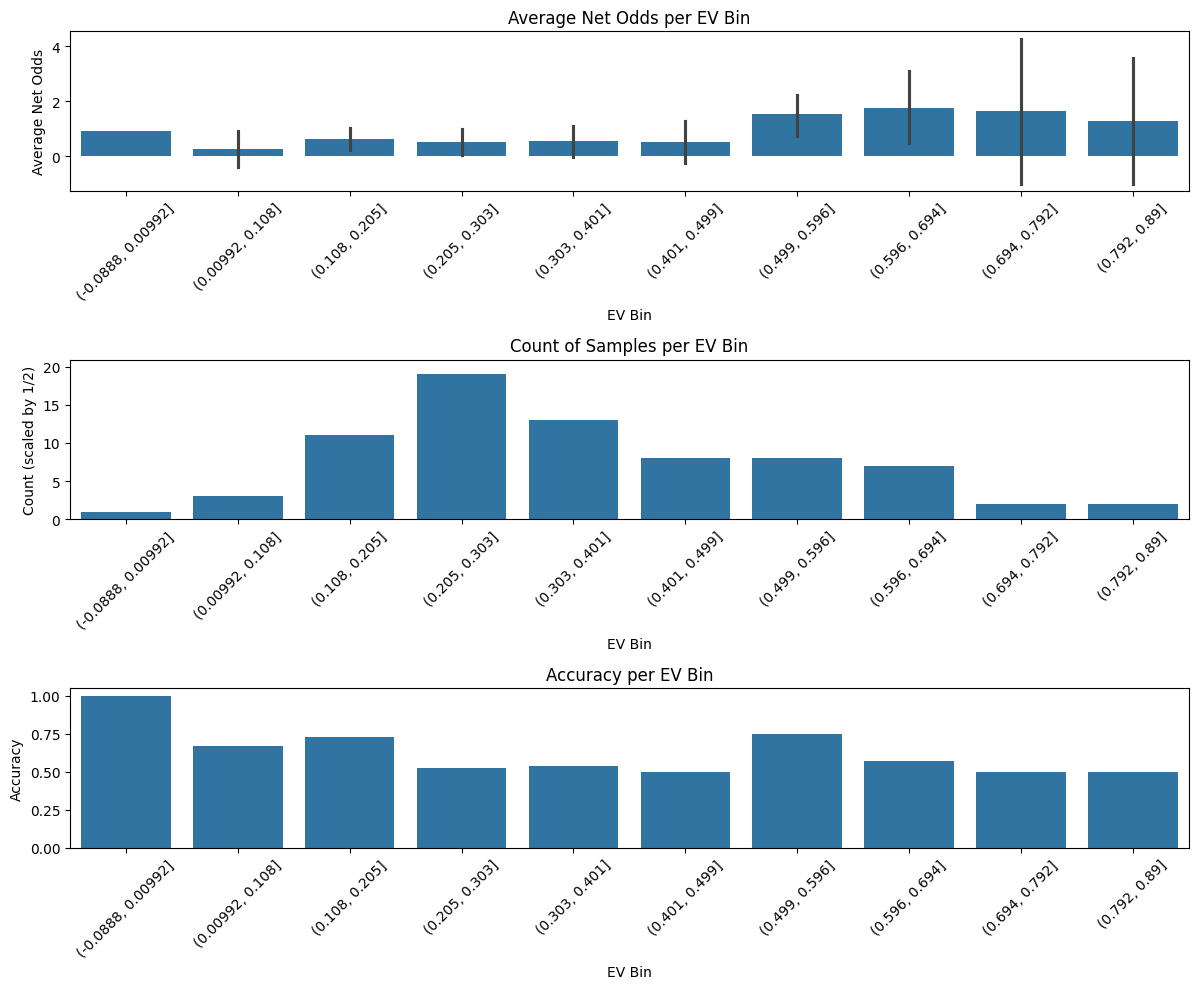

In [14]:
parlay_analysis(df_parlay)

per_bet_analysis(df_kelly)
per_bet_analysis(df_kelly1)
per_bet_analysis(df_kelly2)

In [ ]:
pct_positive = (
    df_kelly.groupby('date')['parlay_net_odds']
      .first()
      .gt(0)
      .mean()
)

pct_positive